In [1]:
import torch
import pandas as pd
import numpy as np
import torchvision.transforms as Tr
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from io import StringIO
from tkinter import filedialog as fd
from scipy.optimize import curve_fit
from matplotlib import pyplot as plt
import nibabel as nib
import matplotlib as mpl
from skimage.exposure import match_histograms
from nilearn import image
from nilearn import plotting
from scipy.ndimage import gaussian_filter
import math
from scipy import optimize, stats
from scipy.optimize import NonlinearConstraint, LinearConstraint, minimize, Bounds, least_squares
import itertools
from sklearn.metrics import mean_squared_error
import matplotlib.patches as patches
import pandas as pd 
from fsl.wrappers.fast import fast as fast
import time
import numpy as np
from matplotlib import pyplot as plt


In [6]:
from contrast_estimation import read_imgs2, seg_to_intenities, calc_hf_snr2, downsample, recombine, tissue_probabilities, toy_values
from contrast_estimation import GridSearch
# from plotting_utils import plot_2_images, plot_4_images

In [8]:
def forward(dataset_folder = "./data_1/"):
    '''
    This function will generate the ground truth data for a given HF Image
    '''
    img_nib = dataset_folder + "T1_brain.nii.gz"
    (img_nib, wm_nib, gm_nib, csf_nib) = read_imgs(dataset_folder)
    (wm_prob, gm_prob, csf_prob, bg_prob) = tissue_probabilities(wm_nib, gm_nib, csf_nib)
    (wm, gm, csf, bg, hf) = seg_to_intenities(img_nib, wm_nib, gm_nib, csf_nib, bg_prob)
    # plot_4_images(wm,gm,csf, hf)
    # plot_rois(wm,gm,csf)
    (wm_snr, gm_snr, csf_snr) = calc_hf_snr(img_nib, wm_nib, gm_nib, csf_nib)
    s, c = toy_values(wm_snr, gm_snr, csf_snr)
    grid = GridSearch(s,c)
    grid_results = grid.solve()
    grid_results = grid.easy_results(grid_results)
    M = grid.select_solution(grid_results)
    print("Solution : ", M)
    (wm_lf_like, gm_lf_like, csf_lf_like, bg_lf_like, lf_like) = recombine(wm, gm, csf, bg, M)
    return (wm_lf_like, gm_lf_like, csf_lf_like, bg_lf_like, lf_like), (wm_prob, gm_prob, csf_prob, bg_prob), (wm_snr, gm_snr, csf_snr), M

In [36]:

def forward2(dataset_folder = "./data_1/", dataset=1):
    '''
    This function will generate the ground truth data for a given HF Image
    '''
        
    dataset_folder = "./" #Temporarily running from the same folder
    img_nib = dataset_folder + "structural_brain.nii.gz"
    (img_nib, wm_nib, gm_nib, csf_nib) = read_imgs2(dataset_folder)
    (wm_prob, gm_prob, csf_prob, bg_prob) = tissue_probabilities(wm_nib, gm_nib, csf_nib)
    (wm, gm, csf, bg, hf) = seg_to_intenities(img_nib, wm_nib, gm_nib, csf_nib, bg_prob)
    (wm_snr, gm_snr, csf_snr) = calc_hf_snr2(img_nib, wm_nib, gm_nib, csf_nib)



    # plot_4_images(wm,gm,csf, hf)
    # plot_rois(wm,gm,csf)

    s, c = toy_values(wm_snr, gm_snr, csf_snr)
    print(s,c)
    grid = GridSearch(s,c)
    grid_results = grid.solve()
    grid_results = grid.easy_results(grid_results)
    M = grid.select_solution(grid_results)
    print("Solution : ", M)
    (wm_lf_like, gm_lf_like, csf_lf_like, bg_lf_like, lf_like) = recombine(wm, gm, csf, bg, M)
    lf_like = lf_like + np.random.normal(3, 3, size=lf_like.shape)
    # plot_4_images(wm_lf_like, gm_lf_like, csf_lf_like, lf_like)#,vmax=[100, 100, 100, 100])
    return (wm_lf_like, gm_lf_like, csf_lf_like, bg_lf_like, lf_like), (wm_prob, gm_prob, csf_prob, bg_prob), (wm_snr, gm_snr, csf_snr), M
    

In [19]:
def plot_4_images(wm, gm, csf, hf, slice = 95, vmax = [100,200,400, 300], titles = ["White Matter", "Gray Matter", "CSF", "High Field Image"], fig_title="Segmentations (Intensitites)"):
    # slice = 95
    fig, axs = plt.subplots(1, 4, figsize=(16, 4))
    im1 = axs[0].imshow(wm[:,:,slice],cmap='gray',vmax = vmax[0])
    im2 = axs[1].imshow(gm[:,:,slice],cmap='gray',vmax = vmax[1])
    im3 = axs[2].imshow(csf[:,:,slice],cmap='gray' ,vmax = vmax[2])
    im4 = axs[3].imshow((hf)[:,:,slice],cmap='gray',vmax = vmax[3])


    axs[0].set_title(titles[0])
    axs[1].set_title(titles[1])
    axs[2].set_title(titles[2])
    axs[3].set_title(titles[3])


    fig.colorbar(im1, ax=axs[0],shrink=0.5)
    fig.colorbar(im2, ax=axs[1],shrink=0.5)
    fig.colorbar(im3, ax=axs[2],shrink=0.5)
    fig.colorbar(im4, ax=axs[3],shrink=0.5)

    fig.suptitle(fig_title, fontsize=14,color='blue')
    plt.show()

In [34]:
def toy_values(wm_snr, gm_snr, csf_snr):
    known_m = np.array([0.4, 0.5, 0.2])
    s = np.array([[wm_snr, 0, -csf_snr], [wm_snr, -gm_snr, 0], [0, gm_snr, -csf_snr] ]) #SNR matrix
    c = toy_c = s @known_m
    print('c = ', c)
    return s, c


# dataset_folder = "./" #Temporarily running from the same folder
# img_nib = dataset_folder + "structural_brain.nii.gz"
# (img_nib, wm_nib, gm_nib, csf_nib) = read_imgs2(dataset_folder)
# (wm_prob, gm_prob, csf_prob, bg_prob) = tissue_probabilities(wm_nib, gm_nib, csf_nib)
# (wm, gm, csf, bg, hf) = seg_to_intenities(img_nib, wm_nib, gm_nib, csf_nib, bg_prob)
# (wm_snr, gm_snr, csf_snr) = calc_hf_snr2(img_nib, wm_nib, gm_nib, csf_nib)
# s, c = toy_values(wm_snr, gm_snr, csf_snr)
# print(s,c)
(wm_lf_like, gm_lf_like, csf_lf_like, bg_lf_like, lf_like), (wm_prob, gm_prob, csf_prob, bg_prob), (wm_snr, gm_snr, csf_snr), M = forward2()

BG Noise in different regions : 5.867293229716557 8.561372573231273 5.378807093419787 15.863190319041825
c =  [14.58544563  0.63956355 13.94588209]
[[ 42.45431133   0.         -11.98139448]
 [ 42.45431133 -32.68432196   0.        ]
 [  0.          32.68432196 -11.98139448]] [14.58544563  0.63956355 13.94588209]


/its/home/pi58/anaconda3/envs/mri_recon/lib/python3.10/site-packages/scipy/optimize/_hessian_update_strategy.py:182: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  warn('delta_grad == 0.0. Check if the approximated '
/its/home/pi58/projects/Super-Resolution/data_2/contrast_estimation.py:279: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df["log_constraint"] = " "


Solution :  [0.4452727  0.55880561 0.36041717]


BG Noise in different regions : 5.867293229716557 8.561372573231273 5.378807093419787 15.863190319041825
c =  [14.58544563  0.63956355 13.94588209]
[[ 42.45431133   0.         -11.98139448]
 [ 42.45431133 -32.68432196   0.        ]
 [  0.          32.68432196 -11.98139448]] [14.58544563  0.63956355 13.94588209]


/its/home/pi58/anaconda3/envs/mri_recon/lib/python3.10/site-packages/scipy/optimize/_hessian_update_strategy.py:182: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  warn('delta_grad == 0.0. Check if the approximated '
/its/home/pi58/projects/Super-Resolution/data_2/contrast_estimation.py:279: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df["log_constraint"] = " "


Solution :  [0.4452727  0.55880561 0.36041717]


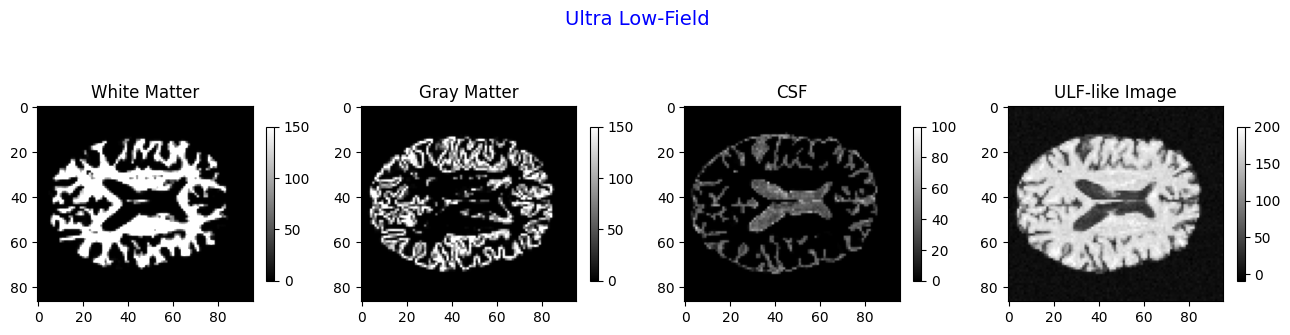

In [37]:
(wm_lf_like, gm_lf_like, csf_lf_like, bg_lf_like, lf_like), (wm_prob, gm_prob, csf_prob, bg_prob), (wm_snr, gm_snr, csf_snr), M = forward2()
plot_4_images(wm_lf_like, gm_lf_like, csf_lf_like, lf_like, vmax = [150,150,100, 300], titles = ["White Matter", "Gray Matter", "CSF", "ULF-like Image"], fig_title="Ultra Low-Field")
plt.close()

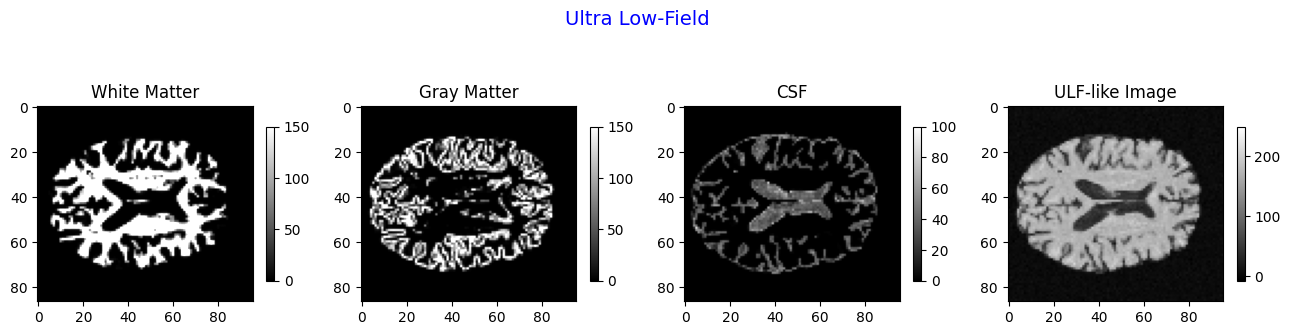

In [39]:
plot_4_images(wm_lf_like, gm_lf_like, csf_lf_like, lf_like, vmax = [150,150,100, 250], titles = ["White Matter", "Gray Matter", "CSF", "ULF-like Image"], fig_title="Ultra Low-Field")


In [21]:
wm_lf_like.shape

(87, 96, 170)

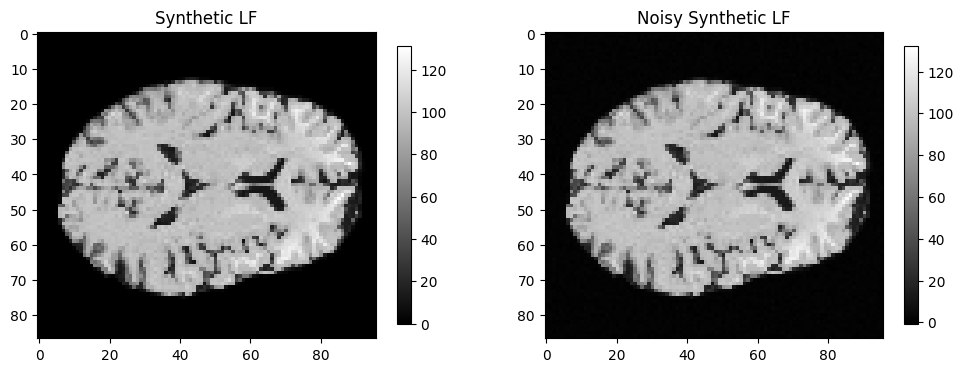

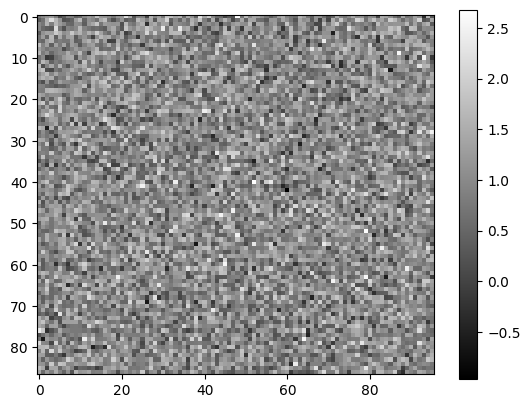

In [31]:
import numpy as np
# noisy_lf_like = torch.from_numpy(lf_like) + (torch.rand_like(torch.from_numpy(lf_like)))
noisy_lf_like = lf_like + np.random.normal(1, 0.5, size=lf_like.shape)
plot_2_images(lf_like[:,:,95], noisy_lf_like[:,:,95],"Synthetic LF", "Noisy Synthetic LF")
plt.imshow((noisy_lf_like[:,:,95] - lf_like[:,:,95]), cmap = 'gray')
plt.colorbar()
plt.show()
plt.close()